In [105]:
import sys
import numpy as np
import anndata as ad
import pandas as pd
import polars as pl

import src as scit

In [106]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')
rna   = ad.read_h5ad('private/data/glue/rna_2025_hmm.h5ad')

In [107]:
cttag.uns['grid']

{'resolution': array([36, 29]),
 'xy': array([[[-3.49477661e-01, -3.49477661e-01, -3.49477661e-01, ...,
          -3.49477661e-01, -3.49477661e-01, -3.49477661e-01],
         [ 3.95101430e-03,  3.95101430e-03,  3.95101430e-03, ...,
           3.95101430e-03,  3.95101430e-03,  3.95101430e-03],
         [ 3.57379690e-01,  3.57379690e-01,  3.57379690e-01, ...,
           3.57379690e-01,  3.57379690e-01,  3.57379690e-01],
         ...,
         [ 1.13136686e+01,  1.13136686e+01,  1.13136686e+01, ...,
           1.13136686e+01,  1.13136686e+01,  1.13136686e+01],
         [ 1.16670973e+01,  1.16670973e+01,  1.16670973e+01, ...,
           1.16670973e+01,  1.16670973e+01,  1.16670973e+01],
         [ 1.20205260e+01,  1.20205260e+01,  1.20205260e+01, ...,
           1.20205260e+01,  1.20205260e+01,  1.20205260e+01]],
 
        [[-1.57239861e+01, -1.54481487e+01, -1.51723113e+01, ...,
          -8.55221275e+00, -8.27637531e+00, -8.00053787e+00],
         [-1.57239861e+01, -1.54481487e+01, -1.51

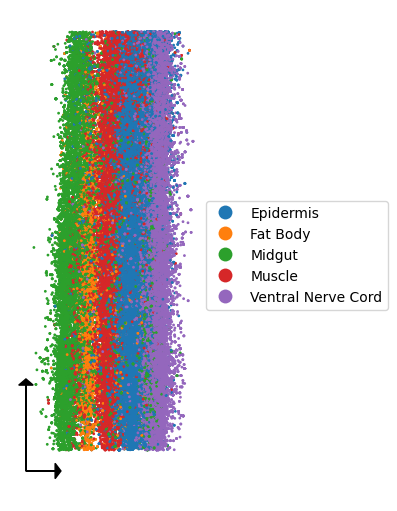

In [108]:
scit.pl.embedding2d(rna, 'X_landscape', 'label_own', size=1)

In [109]:
scit.adv.same_grid((cttag, rna))

In [110]:
lc_acet_imp = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth_imp = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_rna = scit.tl.make_layer_config(
    'rna',
    normalize_with_obs_counts=True,
    log_transform=True,
    feature_active_threshold=2.7,
    feature_names=rna.var_names
)

In [111]:
active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()
active_rna = scit.tl.get_layer_feature_means(rna, lc_rna) > 0.0005

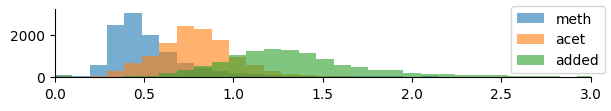

np.int64(4001)

In [112]:
scit.set_defaults(figsize=(6,1))
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    log_transform=False,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    log_transform=False,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lmm = scit.tl.get_layer_feature_means(cttag, lc_meth)
lma = scit.tl.get_layer_feature_means(cttag, lc_acet)
lmb = lma + lmm
scit.pl.int.histogram([lmm, lma, lmb], ['meth', 'acet', 'added'], xminmax=(0,3), bins=200)
mask = lmm > 0.15
mask *= lma > 0.15
mask *= lmb > 1.5
mask.sum()

In [113]:
pl.DataFrame({'name': lc_meth.feature_names, 'mask': mask}).write_csv('private/data/2025_meth_active.csv')


In [114]:
features = np.intersect1d(rna.uns['aligned_features']['names'][active_rna], cttag.uns['gene_names_acet'][mask])
len(features)
#active_meth_al = active_meth[rna.uns['aligned_features']['bin_indices']] * mask

3431

In [115]:
'nau' in features

True

In [116]:
scit.tl.layer_pick_features(rna, lc_rna, features)
scit.adv.griddata_numerical(rna, lc_rna, min_cells=30)

scit.tl.layer_pick_features(cttag, lc_meth_imp, features)
scit.tl.layer_pick_features(cttag, lc_acet_imp, features)
scit.adv.griddata_numerical(cttag, lc_meth_imp, min_cells=8)
scit.adv.griddata_numerical(cttag, lc_acet_imp, min_cells=8)

Info: Added Griddata to .uns[rna]
Info: Added Griddata to .uns[meth]
Info: Added Griddata to .uns[acet]


In [117]:
l = dict(
    gauss_kernel=(1,1), n_median_passes=1, all_feature_q_norm=0.99,
    winsor_qs_high=0.97, data_range_q=0.995#, winsor_qs_low=0.96, winsor_set_low_zero=True
)
max_up_rna = 500#20
max_up_meth = 4
max_up_acet = 1.2
# _CON = 2.5
# for i, n, q in [(0, 'acet_imp', 0.97), (1, 'meth_imp', 0.96), (2, 'rna', 0.95)]:
#     s = data.get_slice(n,use_gauss=True)
#     scaler = 1/np.array([np.quantile(_s.ravel(), q) for _s in s])
#     data.X_gauss[:,:,:,i] = _CON*np.multiply(data.X_gauss[:,:,:,i].T, scaler).T
# 
# from src.advanced._hmm_data import hmm_data_corr_transform
# hmm_data_corr_transform(data, None, [0.97,0.97,0.97,1.0])
# 
# a=np.sign(data.X_gauss)
# data.X_gauss = a*(np.abs(data.X_gauss)**2.2)
# 
# #hmm_data_corr_transform(data, [0.1,0.1,0.1,0], None, set_low_zero=True)
# hmm_data_corr_transform(data, [0.2,0.2,0.2,0.0], None, q_is_p_max=True, set_low_zero=True)
scit.adv.griddata_apply_transformations(rna, lc_rna.layer,        **(l | {'max_up': max_up_rna}))
scit.adv.griddata_apply_transformations(cttag, lc_meth_imp.layer, **(l | {'max_up': max_up_meth}))
scit.adv.griddata_apply_transformations(cttag, lc_acet_imp.layer, **(l | {'max_up': max_up_acet}))

Info: Added Griddata to .uns[t_rna]
Info: Added Griddata to .uns[t_meth]
Info: Added Griddata to .uns[t_acet]


In [118]:
#rna.uns['griddata']['t_rna']['z'] = rna.uns['griddata']['t_rna']['z']**2
#cttag.uns['griddata']['t_meth_imp']['z'] = cttag.uns['griddata']['t_meth_imp']['z']**2
#cttag.uns['griddata']['t_acet_imp']['z'] = cttag.uns['griddata']['t_acet_imp']['z']**2

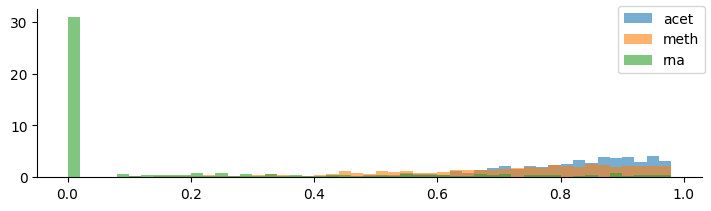

np.int64(500)

In [119]:
scit.set_defaults(figsize=(7,2))
scit.pl.int.histogram(
    [
    cttag.uns['griddata'][f"t_{lc_acet_imp.layer}"]['z'].max(axis=(1,2)),
    cttag.uns['griddata'][f"t_{lc_meth_imp.layer}"]['z'].max(axis=(1,2)),
    rna.uns['griddata']['t_rna']['z'].max(axis=(1,2))
    ],
    [
        'acet', 'meth', 'rna'
    ], max_normalize=True
)
(rna.uns['griddata']['t_rna']['z'].max(axis=(1,2))!=1).sum()

In [120]:
df_acet = scit.adv.griddata_correlations([cttag, rna], [f"t_{lc_acet_imp.layer}", 't_rna'], features, spearman=False, signal_weighting=True, return_raw=False)
df_meth = scit.adv.griddata_correlations([cttag, rna], [f"t_{lc_meth_imp.layer}", 't_rna'], features, spearman=False, signal_weighting=True, return_raw=False)
df = df_acet.join(df_meth, on='var_name', suffix='_meth')
df = df.with_columns(pl.col('res').replace({np.nan: 0}), pl.col('res_meth').replace({np.nan: 0}))
df = df.filter(~((pl.col('res') == 0) & (pl.col('res_meth') == 0)))
df

res,var_name,res_meth
f32,str,f32
-0.099742,"""14-3-3epsilon""",-0.426095
0.137368,"""14-3-3zeta""",-0.194152
0.404182,"""18w""",0.121384
0.093748,"""4E-T""",-0.219072
0.001383,"""5-HT2A""",-0.346902
…,…,…
-0.208268,"""z""",0.571037
0.03331,"""zfh1""",-0.832927
-0.003764,"""zfh2""",-0.613238


In [121]:
# df_acet = scit.adv.griddata_correlations([cttag, rna], [f"t_{lc_acet_imp.layer}", 't_rna'], features, spearman=False, signal_weighting=True, return_raw=True)
# df_meth = scit.adv.griddata_correlations([cttag, rna], [f"t_{lc_meth_imp.layer}", 't_rna'], features, spearman=False, signal_weighting=True, return_raw=True)
# df_acet=df_acet.with_columns(
#     (pl.col('cov') / pl.col('std1') / pl.col('std2')).alias('res')
# )
# df_meth=df_meth.with_columns(
#     (pl.col('cov') / pl.col('std1') / pl.col('std2')).alias('res')
# )
# 
# df = df_acet.join(df_meth, on='var_name', suffix='_meth')
# df = df.with_columns(pl.col('res').replace({np.nan: 0}), pl.col('res_meth').replace({np.nan: 0}))
# df = df.filter(~((pl.col('res') == 0) & (pl.col('res_meth') == 0)))
# df

shape: (1, 3)
┌───────────┬──────────┬──────────┐
│ res       ┆ var_name ┆ res_meth │
│ ---       ┆ ---      ┆ ---      │
│ f32       ┆ str      ┆ f32      │
╞═══════════╪══════════╪══════════╡
│ -0.383632 ┆ nau      ┆ 0.369243 │
└───────────┴──────────┴──────────┘


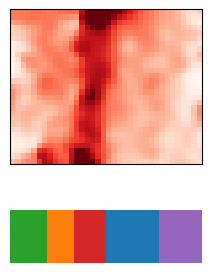

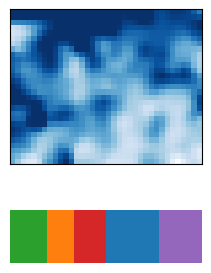

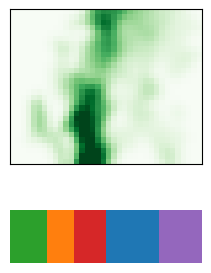

In [122]:
scit.set_defaults(figsize=(2,3))
gn = 'nau'

print(df.filter(pl.col('var_name')==gn))
scit.adv.pl.landscape2d(cttag, f"t_{lc_meth_imp.layer}", gn, cmap='Reds')
scit.adv.pl.landscape2d(cttag, f"t_{lc_acet_imp.layer}", gn, cmap='Blues')
scit.adv.pl.landscape2d(rna, 't_rna', gn, cmap='Greens')

In [123]:
df.filter(pl.col('res') > -1, pl.col('res') < -0.7)

res,var_name,res_meth
f32,str,f32
-0.702052,"""Alp1""",-0.555582
-0.721873,"""Asator""",-0.02008
-0.775128,"""CG10311""",-0.549884
-0.703208,"""CG10339""",-0.856618
-0.72233,"""CG11034""",-0.126002
…,…,…
-0.701543,"""prage""",-0.556317
-0.818037,"""slgA""",-0.881883
-0.717732,"""snoRNA:Or-ACA9""",-0.307357


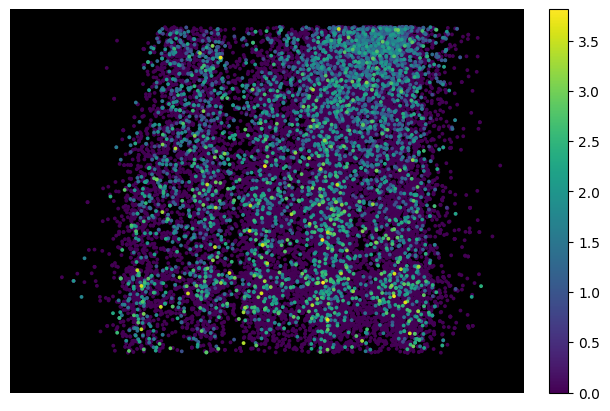

In [124]:
scit.set_defaults(figsize=(6,4))
scit.tl.layer_pick_features(cttag, lc_acet_imp, 'sofe')
scit.tl.copy_to_obs(cttag, lc_acet_imp)
scit.pl.embedding2d(cttag, 'X_landscape', 'copied_data', black_background=True)

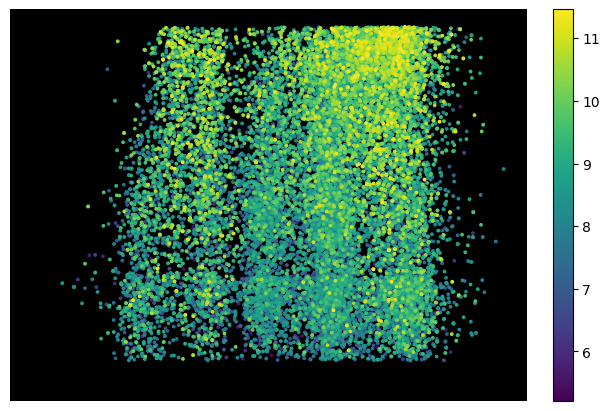

In [125]:
cttag.obs['copied_data'] = np.log2(cttag.obs['acet_total_counts'])
scit.pl.embedding2d(cttag, 'X_landscape', 'copied_data', black_background=True)

In [126]:
# df_cross = scit.adv.griddata_correlations([cttag, cttag], [f"t_{lc_acet_imp.layer}", f"t_{lc_meth_imp.layer}"], features, spearman=False, signal_weighting=True, return_raw=True)
# df_cross

In [127]:

# acs = pl.DataFrame({
#         'var_name': cttag.uns['griddata'][f"t_{lc_acet_imp.layer}"]['feature_names'],
#         'std_acet': cttag.uns['griddata'][f"t_{lc_acet_imp.layer}"]['z'].std(axis=(1,2))
# })
# mes = pl.DataFrame({
#         'var_name': cttag.uns['griddata'][f"t_{lc_meth_imp.layer}"]['feature_names'],
#         'std_meth': cttag.uns['griddata'][f"t_{lc_meth_imp.layer}"]['z'].std(axis=(1,2))
# })
# rns = pl.DataFrame({
#     'var_name': rna.uns['griddata'][f"t_rna"]['feature_names'],
#     'std_rna': rna.uns['griddata'][f"t_rna"]['z'].std(axis=(1,2))
# })
# .join(mes, on='var_name').join(rns, on='var_name').join(acs, on='var_name')

# df = df.join(df_cross, on='var_name', suffix='_cross').with_columns(
#     ((pl.col('cov_meth') - pl.col('cov')) / (pl.col('std_rna') * np.sqrt(pl.col('std_meth')**2 + pl.col('std_acet')**2 - 2*pl.col('cov_cross')))).alias('res_epi')
# ).filter(pl.col('res_epi').is_not_nan())[['cov', 'std1', 'var_name', 'res', 'cov_meth', 'std1_meth', 'res_meth', 'res_epi']]

In [128]:
#def f(x):
#    return np.sign(x) * (x**2)
#vs = (f(df['res']) - f(df['res_meth']))
#df = df.with_columns(
#    (np.sign(vs) * np.sqrt(np.abs(vs))).alias('res_epi')
#)
# def combine(alpha, beta):
#     # Weight each value by its magnitude
#     w_alpha = np.sqrt(np.abs(alpha))
#     w_beta = np.sqrt(np.abs(beta))
#     total_weight = w_alpha + w_beta
#     total_weight[total_weight==0]= 1
#     
#     return (alpha * w_alpha - beta * w_beta) / total_weight

def combine(alpha, beta):

    _alpha = np.arctanh(alpha)
    _beta = np.arctanh(beta)
    
    tau = 1
    return np.tanh((_alpha - _beta) / tau)

df = df.with_columns(
    pl.lit(combine(df['res_meth'].to_numpy(), df['res'].to_numpy())).alias('res_epi')
)


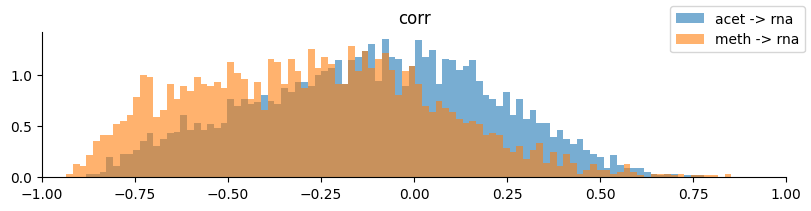

In [129]:
scit.set_defaults(figsize=(8,2))

#_df = df.filter(pl.col('var_name').is_in(cttag.uns['gene_names_acet'][active_meth]))
_df = df
scit.pl.int.histogram([_df['res'], _df['res_meth']], ['acet -> rna', 'meth -> rna'], bins=100, xminmax=(-1,1), max_normalize=True, title='corr', show=False).savefig('private/newest/figures/acme_corr.pdf')

In [130]:
df.filter(pl.col('var_name')=='acj6')

res,var_name,res_meth,res_epi
f32,str,f32,f32
-0.001406,"""acj6""",0.65261,0.653416


In [131]:
# scit.set_defaults(figsize=(7,2))
# scit.pl.int.histogram([df['res_epi']], ['(meth - acet) -> rna'], bins=100, xminmax=(-1,1), max_normalize=True, title='corr')
# scit.set_defaults(figsize=(2,5))
# e = np.array(df['res_epi'])
# scit.pl.int.violin([e], ['(meth - acet) -> rna'] ,show=False)#.savefig('private/newest/figures/epi_rna_corr.pdf')

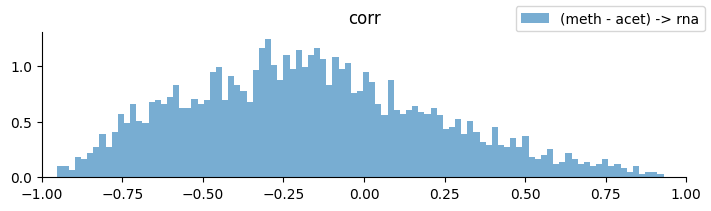

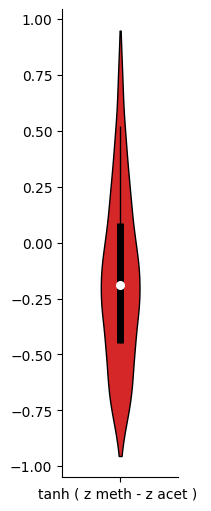

In [132]:
scit.set_defaults(figsize=(7,2))
scit.pl.int.histogram([df['res_epi']], ['(meth - acet) -> rna'], bins=100, xminmax=(-1,1), max_normalize=True, title='corr')
scit.set_defaults(figsize=(2,5))
e = np.array(df['res_epi'])
scit.pl.int.violin([e], ['tanh ( z meth - z acet ) '] ,show=False).savefig('private/newest/figures/epi_rna_corr.pdf')

In [51]:
df.filter(pl.col('res_epi').is_not_nan()).sort('res_epi', descending=True)[0:50]

cov,std1,std2,var_name,res,cov_meth,std1_meth,std2_meth,res_meth,res_epi
f32,f32,f32,str,f32,f32,f32,f32,f32,f32
-0.02729,0.201505,0.25381,"""CG18135""",-0.533598,-0.00347,0.063974,0.221379,-0.245019,1.0
-0.091808,0.256596,0.413876,"""Syt7""",-0.864488,-0.00061,0.010716,0.174239,-0.326682,0.854684
-0.019121,0.169474,0.252435,"""rgr""",-0.446939,0.054071,0.241631,0.257149,0.870208,0.851341
-0.080978,0.236782,0.404698,"""unc79""",-0.845064,-0.000383,0.005652,0.170712,-0.396584,0.826918
-0.004248,0.156074,0.083508,"""CG14694""",-0.325913,0.008902,0.112157,0.387835,0.204657,0.814619
…,…,…,…,…,…,…,…,…,…
-0.033902,0.161443,0.330874,"""neo""",-0.634673,0.000253,0.075127,0.190529,0.017645,0.595819
-0.067933,0.203127,0.4465,"""CG14762""",-0.749018,-0.003107,0.113553,0.243073,-0.112569,0.590331
-0.070514,0.223857,0.391342,"""Ccp84Ag""",-0.804906,-0.011506,0.11504,0.291133,-0.343539,0.587809


In [53]:
df.filter(pl.col('var_name')=='vvl')

cov,std1,std2,var_name,res,cov_meth,std1_meth,std2_meth,res_meth,res_epi
f32,f32,f32,str,f32,f32,f32,f32,f32,f32
0.010092,0.154126,0.175258,"""vvl""",0.373627,-0.037969,0.194262,0.249402,-0.783691,-0.774557


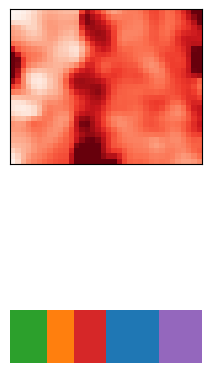

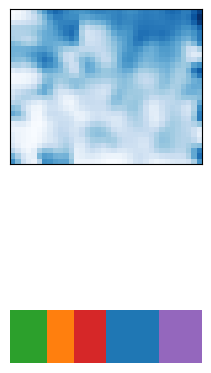

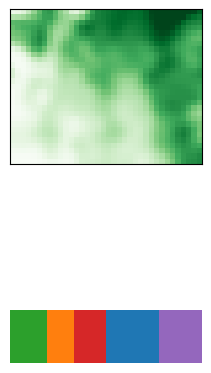

In [101]:
gn = 'Kr'
scit.adv.pl.landscape2d(cttag, f't_{lc_meth_imp.layer}', gn, cmap='Reds')
scit.adv.pl.landscape2d(cttag, f't_{lc_acet_imp.layer}', gn, cmap='Blues')
scit.adv.pl.landscape2d(rna, 't_rna', gn, cmap='Greens')

0.9686938
0.9773228


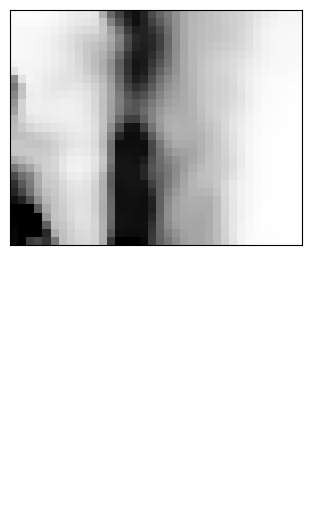

In [98]:
from src.advanced._griddata import _get_griddata_z
from src.advanced.plotting._2d import _get_axes
gd = cttag.uns['griddata']['t_meth_imp']
gd2 = rna.uns['griddata']['t_rna']

zs = (
    _get_griddata_z(gd, gn),
    _get_griddata_z(gd2, gn)
)
print(zs[0].max())
print(zs[1].max())
weights_matrix = ((zs[0])**2 + (zs[1])**2).astype(np.float32)
weights_matrix = np.where(weights_matrix > 1, 1, weights_matrix) ** 2

grid_x, grid_y = gd["grid"]
axs = _get_axes(False, grid_x.shape[1])
#grid_xt, grid_yt = _transform_grid(griddata.grid)
axs[0].imshow(weights_matrix.T, origin='lower', cmap='binary')

In [46]:
df.write_csv('private/data/rna_acme_corr.csv')
acme = pl.read_csv('private/data/acme_corr.csv')

In [70]:
df.filter(pl.col('var_name') == 'vvl')

res,var_name,res_meth,res_epi
f32,str,f32,f32
0.295838,"""vvl""",-0.836979,0.635212


In [8]:
df = pl.read_csv('private/data/rna_acme_corr.csv')

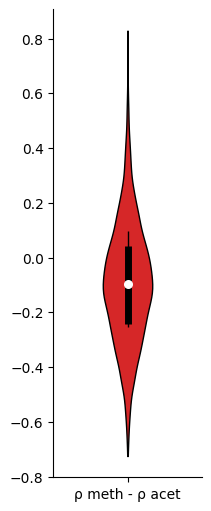

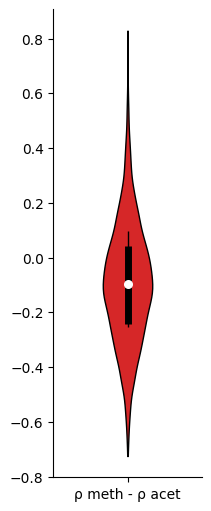

In [48]:
scit.set_defaults(figsize=(2,5))

e = np.array(df['res_epi'])
e[np.isnan(e)] = 0
scit.pl.int.violin([e], ['ρ meth - ρ acet'] ,show=False)#.savefig('private/newest/figures/epi_rna_corr.pdf')


(-1.0, 1.0)

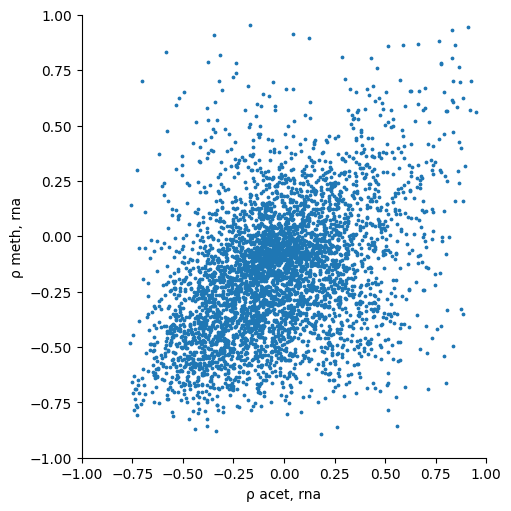

In [53]:
scit.set_defaults(figsize=(5,5))
e = np.array(df['res'])
e[np.isnan(e)] = 0
e_meth = np.array(df['res_meth'])
e_meth[np.isnan(e_meth)] = 0
f=scit.pl.int.scatter([np.c_[e, e_meth]], show=False)#.savefig('private/newest/figures/epi_rna_corr.pdf')
f.axes[0].set_xlabel('ρ acet, rna')
f.axes[0].set_ylabel('ρ meth, rna')
f.axes[0].set_xlim(-1,1)
f.axes[0].set_ylim(-1,1)

#f.savefig('private/newest/figures/corrplot_acme_simple.pdf')

In [144]:
acet_means = scit.tl.get_layer_feature_means(cttag, lc_acet_imp)
meth_means = scit.tl.get_layer_feature_means(cttag, lc_meth_imp)
rna_means = scit.tl.get_layer_feature_means(rna, lc_rna)

_m_df = pl.DataFrame({'name': cttag.uns['gene_names_acet'], 'meth_mean': meth_means, 'acet_mean': acet_means}).join(
    pl.DataFrame({'name': rna.var_names, 'rna_mean': rna_means}), right_on='name', left_on='name'
)


In [145]:
tfs = pl.read_csv('private/data/migri_grn_df.csv')
tfs
#pl.read_csv('private/data/migri_grn_df.txt', has_header=False)['column_1'].to_numpy()

source,degree
str,i64
"""toe""",19
"""ko""",3
"""gsb-n""",2
"""CG31871""",2
"""noc""",1
…,…
"""mask""",1
"""E2f2""",6
"""vvl""",29


In [146]:
df_with_means = df.join(_m_df, right_on='name', left_on='var_name')
df_with_means

res,var_name,res_meth,res_epi,meth_mean,acet_mean,rna_mean
f32,str,f32,f32,f32,f32,f64
0.10829,"""gfzf""",-0.180581,-0.149031,0.30251,0.381025,0.038196
-0.295673,"""CG8043""",0.683151,0.529392,0.658582,0.405838,0.003721
0.404108,"""lncRNA:CR45911""",-0.325922,-0.367115,0.212297,0.403392,0.02803
0.395562,"""CG42788""",0.287466,-0.081244,0.168159,0.282256,0.20116
-0.098328,"""Atg17""",-0.033234,0.049961,0.157104,0.453189,0.125181
…,…,…,…,…,…,…
-0.401566,"""CG32017""",-0.64665,-0.184674,0.100185,0.324236,0.031732
0.205456,"""4E-T""",-0.056417,-0.154211,0.559151,0.547345,0.129719
-0.078274,"""apolpp""",0.1643,0.12917,0.118444,0.408554,1.289515


(-1.0, 1.0)

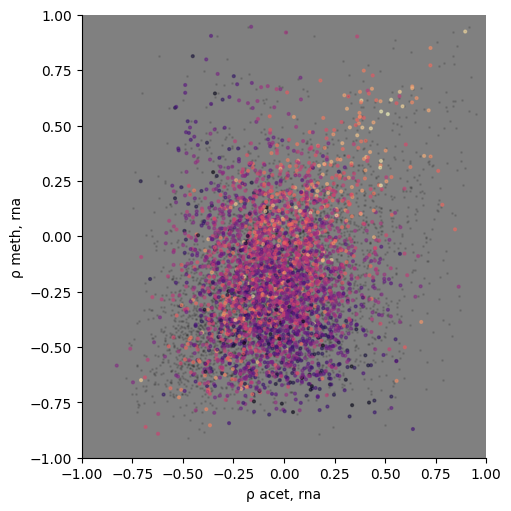

In [147]:
scit.set_defaults(figsize=(5,5))
PICK_TFS = False
COV_LEVEL = False
EPI_LEVEL = True
from src.plotting._quadrant import quad_text
e = np.array(df_with_means['res'])
e_meth = np.array(df_with_means['res_meth'])

import matplotlib.pyplot as plt
from src.plotting._helper import MplWrap
plw = MplWrap(True)
plw.despine()
if PICK_TFS:
    istf = np.isin(df_with_means['var_name'], tfs['source'].to_numpy()).astype(np.bool_)
    print(istf.sum())
    plw.ax.scatter(e[~istf], e_meth[~istf], s=2, alpha=1, c='tab:brown')
    filtered = tfs.filter(pl.col('source').is_in(df_with_means.filter(istf)['var_name']))
    plw.ax.scatter(e[istf], e_meth[istf], s=10, alpha=1, c=np.log2(filtered['degree'].to_numpy()), cmap='magma') #'tab:orange')
if EPI_LEVEL:
    plw.ax.scatter(e, e_meth, s=1, alpha=0.1, c='black')
    _df = acme.join(df_with_means, on='var_name')
    plw.ax.scatter(_df['res'].to_numpy(), _df['res_meth'].to_numpy(), s=4, alpha=0.5, c=_df['res_right'].to_numpy(), cmap='magma')

if COV_LEVEL:
    
    plw.ax.scatter(e, e_meth, s=4, alpha=0.5, c=np.log2(1+100*df_with_means['meth_mean']), cmap='magma')
plw.ax.set_facecolor('gray')

plw.ax.set_xlabel('ρ acet, rna')
plw.ax.set_ylabel('ρ meth, rna')
plw.ax.set_xlim(-1,1)
plw.ax.set_ylim(-1,1)

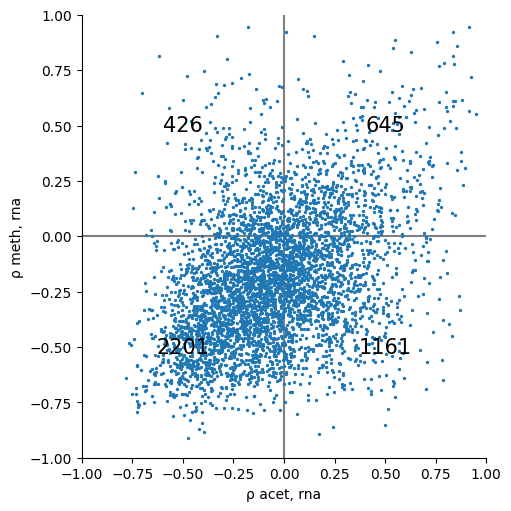

In [148]:
scit.set_defaults(figsize=(5,5))
from src.plotting._quadrant import quad_text
e = np.array(df_with_means['res'])
#e[np.isnan(e)] = 0
e_meth = np.array(df_with_means['res_meth'])

istf = np.isin(df_with_means['var_name'], tfs).astype(np.bool_)
#e_meth[np.isnan(e_meth)] = 0
import matplotlib.pyplot as plt
from src.plotting._helper import MplWrap
plw = MplWrap(True)
plw.despine()
#plw.ax.scatter(e[~istf], e_meth[~istf], s=2, alpha=1, c='tab:blue')
#plw.ax.scatter(e[istf], e_meth[istf], s=4, alpha=1, c='tab:orange')
VT = 0
HT = 0
plw.ax.hlines(HT, -1, 1, color='tab:gray', zorder=0)
plw.ax.vlines(VT, -1, 1, color='tab:gray', zorder=0)

plw.ax.scatter(e, e_meth, s=2, alpha=1, c='tab:blue')

#plw.ax.scatter(e, e_meth, s=4, alpha=0.5, c=np.log2(df_with_means['rna_mean']), cmap='magma')
plw.ax.set_xlabel('ρ acet, rna')
#plw.ax.set_facecolor('gray')
plw.ax.set_ylabel('ρ meth, rna')
plw.ax.set_xlim(-1,1)
plw.ax.set_ylim(-1,1)

#TF_Q1 = istf[((e > VT) * (e_meth > HT))].sum() / ((e > VT) * (e_meth > HT)).sum()
#TF_Q2 = istf[((e < VT) * (e_meth > HT))].sum() / ((e < VT) * (e_meth > HT)).sum()
#TF_Q3 = istf[((e < VT) * (e_meth < HT))].sum() / ((e < VT) * (e_meth < HT)).sum()
#TF_Q4 = istf[((e > VT) * (e_meth < HT))].sum() / ((e > VT) * (e_meth < HT)).sum()
Q1 = ((e > VT) * (e_meth > HT)).sum()
Q2 = ((e < VT) * (e_meth > HT)).sum()
Q3 = ((e < VT) * (e_meth < HT)).sum()
Q4 = ((e > VT) * (e_meth < HT)).sum()
quad_text(
    plw.ax,
    {
        "Q1": str(Q1),
        "Q2": str(Q2),
        "Q3": str(Q3),
        "Q4": str(Q4)
    }
)
#plw.fig.savefig('private/newest/figures/corrplot_acme_wnumbers.pdf')

In [ ]:
scit.set_defaults(figsize=(5,5))
e = np.array(df['res'])
e[np.isnan(e)] = 0
e_meth = np.array(df['res_meth'])
e_meth[np.isnan(e_meth)] = 0
f=scit.pl.int.scatter([np.c_[e, e_meth]], show=False)#.savefig('private/newest/figures/epi_rna_corr.pdf')
f.axes[0].set_xlabel('ρ acet, rna')
f.axes[0].set_ylabel('ρ meth, rna')
f.axes[0].set_xlim(-1,1)
f.axes[0].set_ylim(-1,1)

In [119]:
df.filter(pl.col('res')<-0.5).filter(pl.col('res_meth')<-0.5)

res,var_name,res_meth,res_epi
f32,str,f32,f32
-0.578961,"""AP-2mu""",-0.743042,-0.12322
-0.686012,"""APP-BP1""",-0.675619,0.007795
-0.700452,"""Ack""",-0.652847,0.035708
-0.534158,"""Arp10""",-0.544721,-0.007922
-0.624054,"""Bdbt""",-0.595462,0.021445
…,…,…,…
-0.521247,"""mRpS28""",-0.555021,-0.025333
-0.725935,"""nolo""",-0.789693,-0.047825
-0.538368,"""sced""",-0.506882,0.023616


In [88]:
from copy import deepcopy
cttag.uns['griddata']['t_epi'] = deepcopy(cttag.uns['griddata']["t_meth_imp"])
cttag.uns['griddata']['t_epi']['z'] = cttag.uns['griddata']["t_meth_imp"]['z']# - cttag.uns['griddata']["t_acet_imp"]['z']*0.3

In [89]:
df_epi = scit.adv.griddata_correlations([cttag, rna], ['t_epi', 't_rna'], features, spearman=False, signal_weighting=True)
df_epi.sort(pl.col('res'))

res,var_name
f32,str
-0.918863,"""asRNA:CR46005"""
-0.889268,"""CG6006"""
-0.885968,"""nonA-l"""
-0.876685,"""Pdf"""
-0.876086,"""CG34043"""
…,…
NaN,"""tRNA:Tyr-GTA-1-5"""
NaN,"""trpl"""
NaN,"""upd3"""
